In [1]:
!pip install torch transformers scikit-learn pandas tqdm emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 16.3 MB/s eta 0:00:00


In [2]:
!pip install git+https://github.com/trent-b/iterative-stratification.git

  Cloning https://github.com/trent-b/iterative-stratification.git to /tmp/pip-req-build-6a0ndrxv
  Running command git clone --filter=blob:none --quiet https://github.com/trent-b/iterative-stratification.git /tmp/pip-req-build-6a0ndrxv
  Resolved https://github.com/trent-b/iterative-stratification.git to commit c763bd5440e5f03c6447471305897c1046fc4838
  Preparing metadata (setup.py) ... done
  Created wheel for iterative-stratification: filename=iterative_stratification-0.1.9-py3-none-any.whl size=8444 sha256=8211d8100f472f641914a9208df578cc607482a5d51d01fa49789685d672c5e1
  Stored in directory: /tmp/pip-ephem-wheel-cache-5dtc2l2p/wheels/1a/53/b5/f5f9836cdfff718e36f6af0df976157168f38b5ce6bf53a49d
Successfully built iterative-stratification


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer, RobertaForSequenceClassification, RobertaConfig,  get_linear_schedule_with_warmup
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import emoji
from torch.optim import AdamW
from tqdm import tqdm
import os
from google.colab import files

In [4]:
import torch, random, numpy as np
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

In [5]:
uploaded = files.upload()

Saving goemotions_1.csv to goemotions_1.csv


Token indices sequence length is longer than the specified maximum sequence length for this model (1437 > 512). Running this sequence through the model will result in indexing errors


Sample rows with new columns:
                                                text       id         author  \
0                                    That game hurt.  eew5j0j          Brdd9   
1   >sexuality shouldn’t be a grouping category I...  eemcysk    TheGreen888   
3                                 Man I love reddit.  eeibobj  MrsRobertshaw   
5  Right? Considering it’s such an important docu...  eespn2i   ImperialBoss   
6  He isn't as big, but he's still quite popular....  eczuekb       Rallings   

          subreddit    link_id   parent_id   created_utc  rater_id  \
0               nrl  t3_ajis4z  t1_eew18eq  1.548381e+09         1   
1  unpopularopinion  t3_ai4q37   t3_ai4q37  1.548084e+09        37   
3          facepalm  t3_ahulml   t3_ahulml  1.547965e+09        18   
5        TrueReddit  t3_aizyuz  t1_eesoak0  1.548280e+09        61   
6            cringe  t3_abeksv  t1_eczsmp8  1.546320e+09         3   

   example_very_unclear  admiration  ...  nervousness  optimism  pri

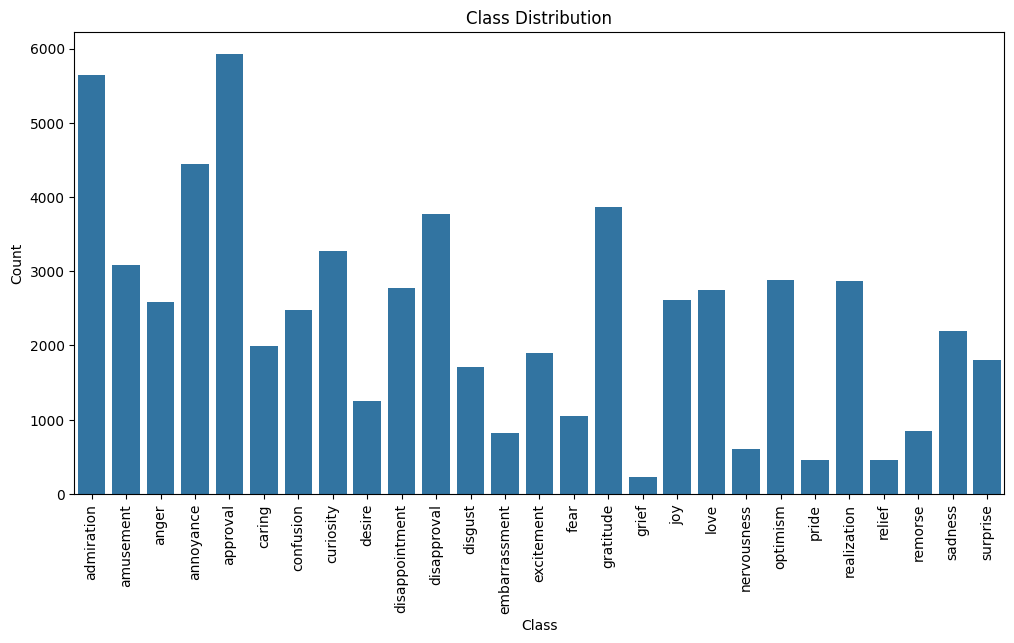

In [21]:
# ----------------------
# 1. Load CSV
# ----------------------
df = pd.read_csv("goemotions_1.csv")
# Get emotion columns (excluding 'text')
emotion_cols = df.columns[9:]  # adjust if your labels start elsewhere

# Remove rows where neutral = 1 and all other labels = 0
df = df[~((df['neutral'] == 1) & (df[emotion_cols].drop('neutral', axis=1).sum(axis=1) == 0))]

# Drop the neutral column entirely
df = df.drop(columns=['neutral'])

# Extract texts and labels
texts = df['text'].values
labels = df[df.columns[9:36]].values  # after 9th col are binary emotions (now without neutral)
label_names = df.columns[9:36].tolist()
num_labels = len(label_names)

# Tokenizer
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

# Add extra columns: word count and token count
def count_words_and_tokens(text):
    words = len(text.split())
    tokens = len(tokenizer.encode(text, add_special_tokens=True))
    return words, tokens

df[["word_count", "token_count"]] = df["text"].apply(lambda x: pd.Series(count_words_and_tokens(x)))
print("Sample rows with new columns:")
print(df.head())

# Count texts containing emojis
emoji_texts = sum(any(char in emoji.EMOJI_DATA for char in t) for t in texts)
print(f"Number of texts containing emojis: {emoji_texts}")

# Emoji handling function
def preprocess_text(text):
    if any(char in emoji.EMOJI_DATA for char in text):
        text = emoji.demojize(text)
    return text

texts = np.array([preprocess_text(t) for t in texts])

# Class distribution
label_counts = np.sum(labels, axis=0)
print("Class distribution (counts per label):")
for name, c in zip(label_names, label_counts):
    print(f"{name}: {c}")

plt.figure(figsize=(12,6))
sns.barplot(x=label_names, y=label_counts)
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [24]:
# Suppose df['token_count'] has the token counts
token_counts = df['token_count'].values

def nth_max(arr, n=1):
    """Return the nth maximum value from an array."""
    unique_vals = np.unique(arr)
    if n > len(unique_vals):
        return None
    sorted_vals = np.sort(unique_vals)[::-1]
    return sorted_vals[n-1]

# Example usage
print("1st max tokens:", nth_max(token_counts, 1))
print("2nd max tokens:", nth_max(token_counts, 2))
print("10th max tokens:", nth_max(token_counts, 10))


1st max tokens: 1437
2nd max tokens: 186
10th max tokens: 60


In [25]:
# Dataset class
class GoEmotionsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = torch.tensor(self.labels[idx], dtype=torch.float)
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': label
        }

In [26]:
# Train/Val/Test split
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(msss.split(texts, labels))
texts_train, texts_test = texts[train_idx], texts[test_idx]
labels_train, labels_test = labels[train_idx], labels[test_idx]

msss_val = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_idx, val_idx = next(msss_val.split(texts_train, labels_train))
texts_train, texts_val = texts_train[train_idx], texts_train[val_idx]
labels_train, labels_val = labels_train[train_idx], labels_train[val_idx]

train_dataset = GoEmotionsDataset(texts_train, labels_train, tokenizer)
val_dataset = GoEmotionsDataset(texts_val, labels_val, tokenizer)
test_dataset = GoEmotionsDataset(texts_test, labels_test, tokenizer)

def collate_fn(batch):
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])
    labels = torch.stack([item['labels'] for item in batch])
    return {'input_ids': input_ids, 'attention_mask': attention_mask, 'labels': labels}

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)

print("Train size:", len(texts_train))
print("Val size:", len(texts_val))
print("Test size:", len(texts_test))



Train size: 37134
Val size: 4127
Test size: 10316


In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        """
        alpha : weighting factor for positive vs negative class
        gamma : focusing parameter to reduce loss for well-classified examples
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        """
        logits : raw model outputs (before sigmoid)
        targets: binary labels (0/1), same shape as logits
        """
        probs = torch.sigmoid(logits)
        ce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t = probs * targets + (1 - probs) * (1 - targets)
        loss = self.alpha * (1 - p_t) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss


In [28]:
# Model setup
device = (
    torch.device("cuda") if torch.cuda.is_available() else
    torch.device("xla") if "xla" in torch.backends.__dict__ and torch.backends.xla.is_available() else
    torch.device("cpu")
)

config = RobertaConfig.from_pretrained("roberta-base",
                                             num_labels=num_labels,
                                             problem_type="multi_label_classification",
                                             dropout=0.05)

model = RobertaForSequenceClassification.from_pretrained("roberta-base", config=config)
model.to(device)

epochs = 5
optimizer = AdamW(model.parameters(), lr=5e-5, weight_decay=0.15)
criterion = FocalLoss(alpha=1, gamma=2, reduction='mean')

num_training_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * num_training_steps), num_training_steps=num_training_steps)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [29]:
# Training + Validation loop

best_val_f1 = 0.0
best_model_state = None

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    model.train()
    train_loss = 0
    for batch in tqdm(train_loader):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()
    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0
    preds, true_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            loss = criterion(logits, labels)
            val_loss += loss.item()
            preds.extend(torch.sigmoid(logits).cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    avg_val_loss = val_loss / len(val_loader)
    preds = np.array(preds) > 0.5
    val_f1 = f1_score(true_labels, preds, average="micro")
    val_acc = accuracy_score(true_labels, preds)
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = model.state_dict()

model.load_state_dict(best_model_state)
print(f"\nBest validation F1 after {epochs} epochs: {best_val_f1:.4f}")


Epoch 1/5


100%|██████████| 2321/2321 [07:45<00:00,  4.98it/s]


Train Loss: 0.0444 | Val Loss: 0.0350
Val Accuracy: 0.2299 | Val F1: 0.3522

Epoch 2/5


100%|██████████| 2321/2321 [07:44<00:00,  4.99it/s]


Train Loss: 0.0340 | Val Loss: 0.0343
Val Accuracy: 0.2559 | Val F1: 0.3877

Epoch 3/5


...

Train Loss: 0.0307 | Val Loss: 0.0340
Val Accuracy: 0.2496 | Val F1: 0.3786

Epoch 4/5


100%|██████████| 2321/2321 [07:44<00:00,  5.00it/s]


Train Loss: 0.0270 | Val Loss: 0.0354
Val Accuracy: 0.2828 | Val F1: 0.4133

Epoch 5/5


100%|██████████| 2321/2321 [07:44<00:00,  5.00it/s]


Train Loss: 0.0234 | Val Loss: 0.0373
Val Accuracy: 0.2864 | Val F1: 0.4200

Best validation F1 after 5 epochs: 0.4200


In [30]:
# Test loop
model.eval()
test_preds, test_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        test_preds.extend(torch.sigmoid(logits).cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_preds = (torch.tensor(np.array(test_preds)) >= 0.5).int()
test_labels = torch.tensor(np.array(test_labels)).int()
test_acc = accuracy_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds, average='micro')
print(f"Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}")
test_precision = precision_score(test_labels, test_preds, average='micro', zero_division=0)
test_recall = recall_score(test_labels, test_preds, average='micro', zero_division=0)
print(f"Test Precision: {test_precision:.4f}, Test Recall: {test_recall:.4f}")
cm = confusion_matrix(test_labels.view(-1), test_preds.view(-1))
print("Confusion Matrix (flattened across all labels):")
print(cm)


Test Acc: 0.2927, Test F1: 0.4342
Test Precision: 0.5340, Test Recall: 0.3658
Confusion Matrix (flattened across all labels):
[[261589   4099]
 [  8146   4698]]


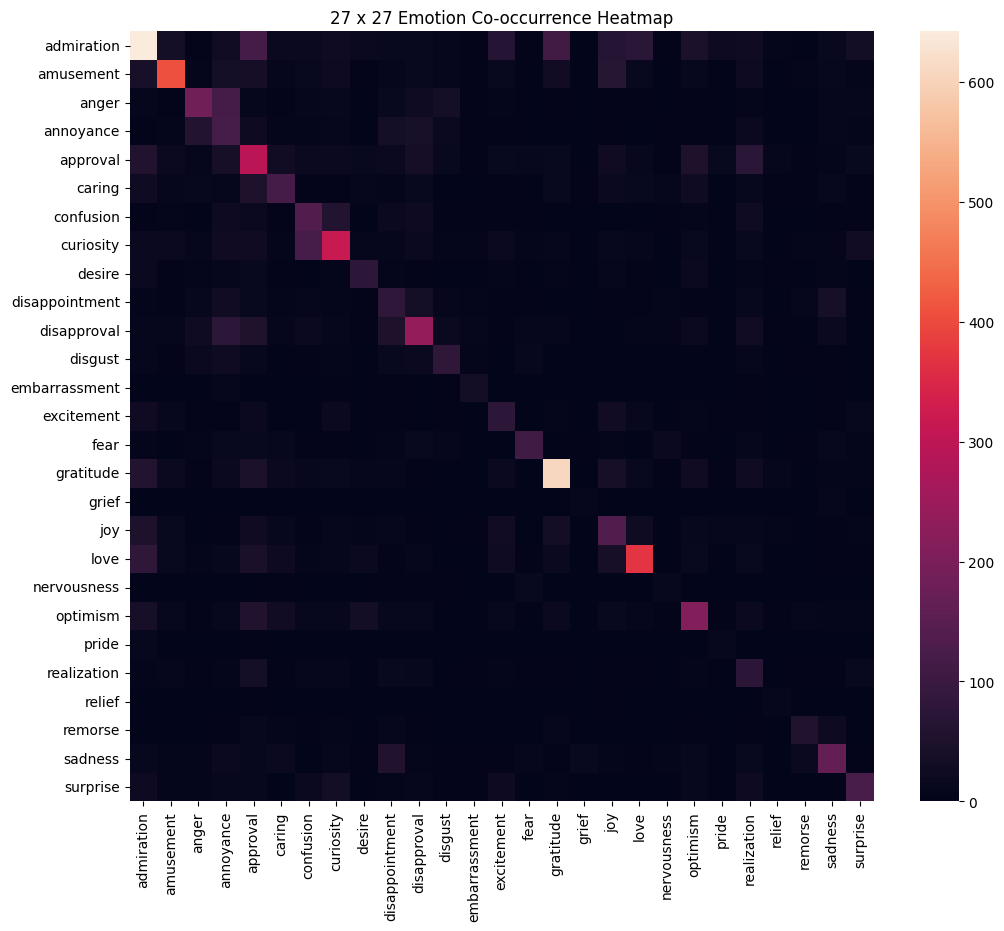

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import multilabel_confusion_matrix

mcm = multilabel_confusion_matrix(test_labels.numpy(), test_preds.numpy())

# sum across TN/FP/FN/TP if you want a 28x28 style heatmap of co-predictions
heatmap_data = np.zeros((27, 27))
for i in range(27):
    for j in range(27):
        # approximate co-occurrence in predictions vs true
        heatmap_data[i, j] = ((test_preds[:, i] == 1) & (test_labels[:, j] == 1)).sum()

plt.figure(figsize=(12,10))
sns.heatmap(heatmap_data, xticklabels=label_names, yticklabels=label_names, cmap='rocket',  annot=False)
plt.title("27 x 27 Emotion Co-occurrence Heatmap")
plt.show()


In [32]:
# Prediction function
def predict_emotions(text, top_k=5):
    model.eval()
    encoding = tokenizer(text, truncation=True, padding='max_length', max_length=64, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model(**encoding)
        probs = torch.sigmoid(outputs.logits).cpu().numpy()[0]
    top_indices = probs.argsort()[-top_k:][::-1]
    return [(label_names[i], float(probs[i])) for i in top_indices]

user_text = input("Enter a text: ")
print("\nUser Input:", user_text)
print("Predicted Emotions:")
for label, score in predict_emotions(user_text):
    print(f"{label}: {score:.4f}")

Enter a text: At my temporary job, I have to restrict  others' actions and make   them obey me, and this very often gives me  a feeling of guilt.

User Input: At my temporary job, I have to restrict  others' actions and make   them obey me, and this very often gives me  a feeling of guilt.
Predicted Emotions:
remorse: 0.4767
embarrassment: 0.4375
sadness: 0.3400
realization: 0.3290
disappointment: 0.3074


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Save & download model
model.save_pretrained("goemotions_roberta")
tokenizer.save_pretrained("goemotions_roberta")
!zip -r goemotions_roberta.zip goemotions_roberta
files.download("goemotions_roberta.zip")



In [ ]:
# Reload model from uploaded zip
# uploaded = files.upload()
# !unzip -o goemotions_roberta.zip -d ./
# loaded_model = RobertaForSequenceClassification.from_pretrained("goemotions_roberta")
# loaded_tokenizer = RobertaTokenizer.from_pretrained("goemotions_roberta")

In [3]:
import torch
from transformers import RobertaTokenizer, RobertaForSequenceClassification
import numpy as np

c:\Users\karth\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:

# Path to your unzipped model folder
MODEL_PATH = "./goemotions_roberta"

print("Loading model and tokenizer...")
tokenizer = RobertaTokenizer.from_pretrained(MODEL_PATH)
model = RobertaForSequenceClassification.from_pretrained(MODEL_PATH)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Your 27 emotion labels (no neutral)
label_names = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring",
    "confusion", "curiosity", "desire", "disappointment", "disapproval",
    "disgust", "embarrassment", "excitement", "fear", "gratitude",
    "grief", "joy", "love", "nervousness", "optimism", "pride",
    "realization", "relief", "remorse", "sadness", "surprise"
]

Loading model and tokenizer...


In [14]:

def predict_emotions(text, top_k=5):
    """Return top-k emotion predictions for the input text."""
    encoding = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=128,
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        outputs = model(**encoding)
        probs = torch.sigmoid(outputs.logits).cpu().numpy()[0]

    top_indices = probs.argsort()[-top_k:][::-1]
    return [(label_names[i], float(probs[i])) for i in top_indices]

In [16]:
# Interactive loop

text = input("\nEnter a text to analyze (or type 'exit' to quit): ").strip()
print("Text entered:", text)
predictions = predict_emotions(text)
print("\nPredicted Emotions:")
for label, score in predictions:
    print(f"{label:<15}: {score:.4f}")

Text entered: i ffel like my stomach is gona explode

Predicted Emotions:
fear           : 0.3623
excitement     : 0.3308
nervousness    : 0.3011
optimism       : 0.2741
amusement      : 0.2579
